# 03 — Job-Role Classifier (TF-IDF vs. Sentence Embeddings)

**Goal:** given the text of a resume, predict *which job role it belongs to* (e.g. "Data Analyst",
"Web Developer") and say how confident we are. This powers `recommend_roles()` in `app/recommender.py`.

This is called **text classification**: we show the computer many resumes whose role we already know,
it learns patterns, and then it guesses the role of resumes it has never seen.

**What we'll do, in order**

| Step | What happens | Why |
|---|---|---|
| 1 | Load `resume_dataset.csv` | Get the real data |
| 2 | Explore it (EDA) | Spot problems before modelling |
| 3 | Clean the text with `light_clean()` | Remove messy characters |
| 4 | Split into train / test (stratified) | Keep an honest "exam" the model never studies |
| 5 | **Model A:** TF-IDF + Logistic Regression | Classic, fast, readable baseline |
| 6 | **Model B:** Sentence embeddings + Logistic Regression | Understands *meaning*, not just words |
| 7 | Compare A and B | Decide which is better |
| 8 | Save the winner with `joblib` to `app/models/` | So the API can load it |
| 9 | Try `recommend_roles()` | Prove the saved model works end-to-end |

> **Where this file lives:** `resume-analyzer/notebooks/03_job_classifier.ipynb`
> **Dataset expected at:** `resume-analyzer/app/data/resume_dataset.csv`
> **Model will be written to:** `resume-analyzer/app/models/job_classifier.joblib`

In [1]:
# ── Cell 1 : Setup ──────────────────────────────────────────────────────────
# Same trick as notebooks 01 and 02: put the project root on the Python path
# so `from app... import ...` works when the notebook runs from notebooks/.
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.base import clone
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, log_loss
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline

# Our own project code
from app.preprocess import light_clean
from app.recommender import MODEL_DIR, MODEL_PATH, embed_resumes

DATA_PATH = PROJECT_ROOT / "app" / "data" / "resume_dataset.csv"
RANDOM_STATE = 42          # makes every "random" step repeatable
sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)

print("Project root :", PROJECT_ROOT)
print("Dataset path :", DATA_PATH, "->", "found" if DATA_PATH.exists() else "NOT FOUND")
print("scikit-learn :", sklearn.__version__)

Project root : C:\Users\PMLS\resume-analyzer
Dataset path : C:\Users\PMLS\resume-analyzer\app\data\resume_dataset.csv -> found
scikit-learn : 1.9.1


---
## Step 1 — Load the dataset

`pandas` reads the CSV into a table called a **DataFrame**. Our file has two columns:

- `Category` — the job role (this is the **label** we want to predict)
- `Resume_str` — the resume text (this is the **input**)

We check the basics first: how many rows, any missing values, any duplicates. Bad data in = bad model out.

In [2]:
# ── Cell 2 : Load & inspect ─────────────────────────────────────────────────
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Put resume_dataset.csv at {DATA_PATH} (create the app/data folder if needed)."
    )

df = pd.read_csv(DATA_PATH)

print("Shape (rows, columns):", df.shape)
print("\nColumn types:\n", df.dtypes)
print("\nMissing values per column:\n", df.isna().sum())
print("\nDuplicate rows       :", df.duplicated().sum())
print("Duplicate resume text:", df["Resume_str"].duplicated().sum())
df.head(3)

Shape (rows, columns): (1034, 2)

Column types:
 Category      str
Resume_str    str
dtype: object

Missing values per column:
 Category      0
Resume_str    0
dtype: int64

Duplicate rows       : 0
Duplicate resume text: 0


,Category,Resume_str
0,Database Administrator,Profile: Seeking to apply my skills in RMAN an...
1,Cyber Security,SUMMARY: An entry-level professional with inte...
2,Marketing,"Social Media Manager based in Toronto, ON. Pro..."


In [3]:
# ── Cell 3 : Look at one real resume per role ───────────────────────────────
# Reading real examples tells you things statistics can't.
for cat in df["Category"].unique()[:3]:
    print(f"[{cat}]")
    print(df.loc[df["Category"] == cat, "Resume_str"].iloc[0][:350], "...\n")

[Database Administrator]
Profile: Seeking to apply my skills in RMAN and MySQL to a fintech organization. Comfortable working independently or as part of a team. Key Skills: PostgreSQL; data migration; user access management; MySQL; Bash; Linux; capacity planning. Tools: Redgate, Nagios, pgAdmin, Percona Toolkit Employment History: Senior Database Administrator, Cobalt Lab ...

[Cyber Security]
SUMMARY: An entry-level professional with internship and project experience in telecom. EDUCATION: B.S. in Computer Science, National University, 2025. CORE COMPETENCIES: SQL / malware analysis / OWASP Top 10 / ISO 27001 / encryption / vulnerability assessment / Python / phishing analysis / NIST framework / log analysis / SOC / endpoint security /  ...

[Marketing]
Social Media Manager based in Toronto, ON. Profile: Social Media Manager (Entry-level) specializing in brand strategy, conversion optimization, and lead nurturing. Known for reliability, ownership, and clear communication. Education: 

---
## Step 2 — Exploratory Data Analysis (EDA)

EDA = "look before you leap". Two questions matter most:

1. **Are the classes balanced?** If one role had 900 resumes and another had 20, a lazy model could just
   always guess the big one and still look accurate. We'd then need extra care (class weights, different metrics).
2. **How long are the resumes?** Very short or very long texts can need special handling.

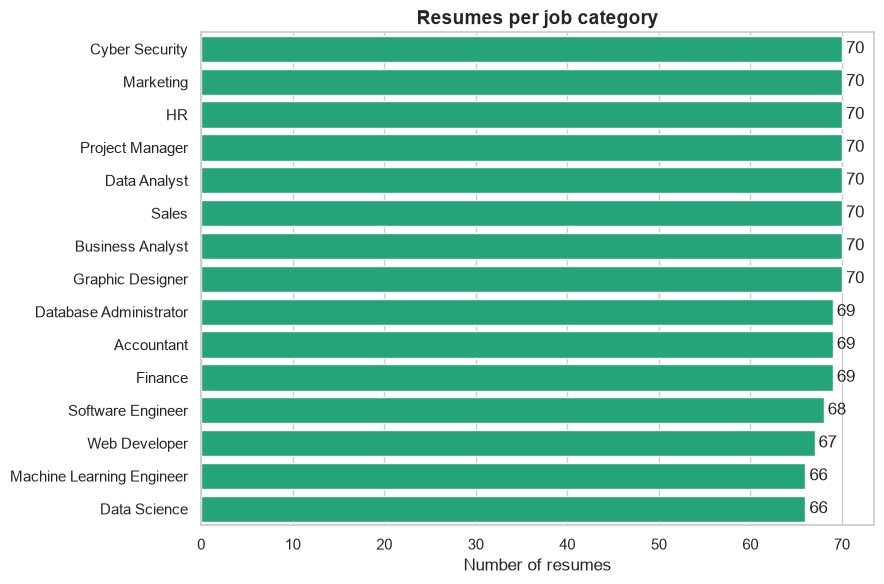

15 categories | smallest = 66 | largest = 70 | ratio = 1.06x


In [4]:
# ── Cell 4 : Class distribution plot ────────────────────────────────────────
counts = df["Category"].value_counts()

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=counts.values, y=counts.index, color="#10B981", ax=ax)
ax.bar_label(ax.containers[0], padding=3)
ax.set_title("Resumes per job category", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of resumes")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

print(f"{counts.size} categories | smallest = {counts.min()} | largest = {counts.max()} "
      f"| ratio = {counts.max() / counts.min():.2f}x")

**How to read this:** every role has roughly the same number of resumes (about 66–70), so the data is
**well balanced**. That means plain **accuracy** is a fair score, and we don't need tricks like resampling.
We'll still report **macro-F1** too — it averages performance across *every* role equally, so a weak role can't hide.

We also have only **~1,000 resumes in total**, which is small. That's why we use a *stratified* split and
*cross-validation* below, and why we keep the models simple.

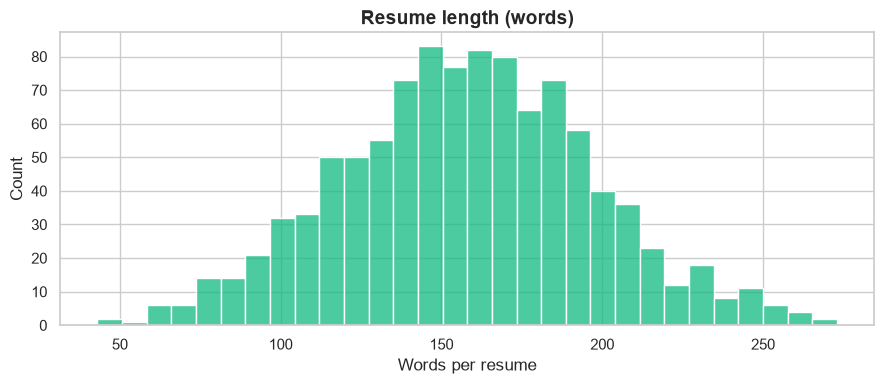

,n_chars,n_words
count,1034.0,1034.0
mean,1146.0,158.0
std,280.0,39.0
min,341.0,43.0
25%,962.0,131.0
50%,1154.0,158.0
75%,1328.0,184.0
max,2010.0,273.0


In [5]:
# ── Cell 5 : Resume length ──────────────────────────────────────────────────
df["n_chars"] = df["Resume_str"].str.len()
df["n_words"] = df["Resume_str"].str.split().str.len()

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(df["n_words"], bins=30, color="#10B981", ax=ax)
ax.set_title("Resume length (words)", fontsize=14, fontweight="bold")
ax.set_xlabel("Words per resume")
plt.tight_layout()
plt.show()

df[["n_chars", "n_words"]].describe().round(0)

**How to read this:** resumes are fairly uniform (roughly 45–275 words, centred near 160). Nothing is empty and
there are no extreme outliers, so we don't need to filter any rows.

One more thing worth knowing: every resume here is stored as **one long line** (no line breaks). That matters later
for the embedding model, which has to split the text into sentences using punctuation alone.

---
## Step 3 — Clean the text with *your* `preprocess.py`

Your project has two cleaning levels:

| Function | What it does | Best for |
|---|---|---|
| `light_clean()` | Fixes odd Unicode, curly quotes, bullets, extra spaces. **Keeps words and sentences intact.** | Embedding models, TF-IDF |
| `nlp_process()` | Tokenises, removes stop-words, lemmatises with spaCy | Keyword analysis |

We use **`light_clean()` for both models**, for two reasons:

- **Sentence embeddings** understand *whole sentences*. Removing stop-words or chopping words down to lemmas would
  damage the meaning they rely on (this is exactly what the docstring in your `preprocess.py` says).
- **TF-IDF** already lowercases text and drops stop-words by itself (we switch that on in the vectoriser), so running
  `nlp_process()` first would add ~1,000 slow spaCy calls without much benefit.

Using the *same* cleaning for both models also keeps the comparison fair.

In [6]:
# ── Cell 6 : Apply light_clean to every resume ──────────────────────────────
def safe_clean(text: str) -> str:
    # light_clean raises ValueError if nothing is left; return "" so we can drop such rows.
    try:
        return light_clean(text)
    except ValueError:
        return ""

df["clean_text"] = df["Resume_str"].apply(safe_clean)

empty_rows = (df["clean_text"] == "").sum()
print("Rows that became empty after cleaning:", empty_rows)
df = df[df["clean_text"] != ""].reset_index(drop=True)

# Before / after for one resume
i = 0
print("\nBEFORE:", df.loc[i, "Resume_str"][:250])
print("AFTER :", df.loc[i, "clean_text"][:250])
print("\nCharacters changed on average:",
      round((df["Resume_str"].str.len() - df["clean_text"].str.len()).abs().mean(), 2))

Rows that became empty after cleaning: 0

BEFORE: Profile: Seeking to apply my skills in RMAN and MySQL to a fintech organization. Comfortable working independently or as part of a team. Key Skills: PostgreSQL; data migration; user access management; MySQL; Bash; Linux; capacity planning. Tools: Red
AFTER : Profile: Seeking to apply my skills in RMAN and MySQL to a fintech organization. Comfortable working independently or as part of a team. Key Skills: PostgreSQL; data migration; user access management; MySQL; Bash; Linux; capacity planning. Tools: Red

Characters changed on average: 0.0


The text was already quite tidy, so cleaning changes little — that's fine. It's a safety net that guarantees the
**same cleaning at training time and at prediction time** (`recommend_roles()` calls `light_clean()` too).

---
## Step 4 — Train / test split (stratified)

Think of a student: if you give them the exam questions to study from, a good score proves nothing.
So we hide **20% of resumes** (the **test set**) and train only on the other 80% (the **training set**).
At the end we grade the model on the hidden 20%.

**Stratified** means each role keeps the same share in both sets. Without it, by bad luck the test set could
contain only 3 "HR" resumes and 20 "Sales" ones, which would make scores unreliable.
`random_state=42` makes the split identical every time you run the notebook.

In [7]:
# ── Cell 7 : Stratified split ───────────────────────────────────────────────
X = df["clean_text"]
y = df["Category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {len(X_train)} resumes | Test: {len(X_test)} resumes")

# Prove stratification worked: class shares should be nearly identical
share = pd.DataFrame({
    "train_%": (y_train.value_counts(normalize=True) * 100).round(1),
    "test_%":  (y_test.value_counts(normalize=True) * 100).round(1),
})
share

Train: 827 resumes | Test: 207 resumes


,train_%,test_%
Category,,
Accountant,6.7,6.8
Business Analyst,6.8,6.8
Cyber Security,6.8,6.8
Data Analyst,6.8,6.8
Data Science,6.4,6.3
Database Administrator,6.7,6.8
Finance,6.7,6.8
Graphic Designer,6.8,6.8
HR,6.8,6.8


**How to read this:** the train and test percentages match closely for every role, so the exam is representative.

**Cross-validation (used next).** To choose settings (like the regularisation strength `C`), we *don't* peek at the
test set. Instead we split the **training** set into 5 parts, train on 4 and check on the 5th, rotating 5 times.
The test set stays untouched until the final grade.

In [8]:
# ── Cell 8 : Shared evaluation helpers ──────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def evaluate(name, y_true, y_pred, y_proba, classes):
    # Headline scores for a model on the hidden test set.
    return {
        "model": name,
        "test_accuracy": accuracy_score(y_true, y_pred),
        "test_macro_f1": f1_score(y_true, y_pred, average="macro"),
        "test_log_loss": log_loss(y_true, y_proba, labels=classes),
    }

# We track two things during tuning:
#   f1_macro      -> "how often is the top guess right?"  (used to JUDGE models)
#   neg_log_loss  -> "are the percentages trustworthy?"    (used to PICK the setting C)
SCORING = {"f1_macro": "f1_macro", "neg_log_loss": "neg_log_loss"}

def cv_summary(grid):
    # Pull the cross-validated scores of the setting GridSearchCV selected.
    i = grid.best_index_
    return {
        "cv_macro_f1": grid.cv_results_["mean_test_f1_macro"][i],
        "cv_log_loss": -grid.cv_results_["mean_test_neg_log_loss"][i],
    }

---
## Step 5 — Model A: TF-IDF + Logistic Regression

### TF-IDF in plain words
Computers can't read words, only numbers. **TF-IDF** turns each resume into a list of numbers, one per word
(or word-pair) in the vocabulary:

- **TF (term frequency):** how often the word appears in *this* resume.
- **IDF (inverse document frequency):** how *rare* the word is across *all* resumes.

Common words like "experience" appear everywhere, so they get a low weight. A word like "Kubernetes" or "Tableau"
is rare and telling, so it gets a high weight. The result: words that *distinguish* roles shine.

Our settings:
- `ngram_range=(1, 2)` → also use two-word phrases like "machine learning" or "tax return".
- `stop_words="english"` → drop "the", "and", "of"…
- `min_df=2` → ignore words that appear in only one resume (probably noise or names).
- `sublinear_tf=True` → saying "Python" 10 times isn't 10× better than saying it once.
- a custom `token_pattern` that keeps `c++` and `c#` in one piece (the default would chop them).

### Logistic Regression in plain words
Despite the name, it's a classifier. For each role it learns a weight per word ("Tableau" pushes towards
*Data Analyst*, "Figma" pushes towards *Graphic Designer*), adds up the evidence, and turns the totals into
**probabilities that sum to 100%**. That is exactly what we need for "Data Science: 62%".

### Tuning `C` (and why we use *log loss*)
`C` controls how strongly the model is stopped from memorising. Small `C` = very cautious (and therefore
*hesitant*: it hands out modest percentages), large `C` = trusts the training data more. We try several values with
cross-validation (`GridSearchCV`).

We track two scores:
- **macro-F1** — "is the top guess right?" We use it to **judge** models.
- **log loss** — "can we trust the percentages?" It punishes confident wrong answers and also punishes
  needless hesitation (lower is better). Because `recommend_roles()` shows *percentages* to users, we use it to
  **pick `C`**.

(On this dataset several values of `C` tie perfectly on macro-F1, so without log loss `GridSearchCV` would just
take the first one, the most hesitant, which gives needlessly low percentages.)

In [9]:
# ── Cell 9 : Train Model A ──────────────────────────────────────────────────
tfidf_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True,
        token_pattern=r"(?u)\b\w[\w+#]*",
    )),
    ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])

grid_tfidf = GridSearchCV(
    tfidf_pipe,
    param_grid={"clf__C": [1, 10, 100]},   # stop at 100: beyond that the model is almost unregularised
    cv=cv, scoring=SCORING, refit="neg_log_loss", n_jobs=1,
)
grid_tfidf.fit(X_train, y_train)

pred_tfidf  = grid_tfidf.predict(X_test)
proba_tfidf = grid_tfidf.predict_proba(X_test)
res_tfidf = evaluate("TF-IDF + LR", y_test, pred_tfidf, proba_tfidf, grid_tfidf.classes_)
res_tfidf.update(cv_summary(grid_tfidf))

print("Best C                :", grid_tfidf.best_params_["clf__C"])
print(f"Cross-val macro-F1    : {res_tfidf['cv_macro_f1']:.4f}   (training data only)")
print(f"Cross-val log loss    : {res_tfidf['cv_log_loss']:.4f}   (lower is better)")
print(f"Test accuracy         : {res_tfidf['test_accuracy']:.4f}")
print(f"Test macro-F1         : {res_tfidf['test_macro_f1']:.4f}")
print(f"Test log loss         : {res_tfidf['test_log_loss']:.4f}")

Best C                : 100
Cross-val macro-F1    : 1.0000   (training data only)
Cross-val log loss    : 0.0159   (lower is better)
Test accuracy         : 1.0000
Test macro-F1         : 1.0000
Test log loss         : 0.0165


### What did Model A actually learn?
A model you can't inspect is hard to trust. Below are the **words with the biggest positive weight** for each role.
If these look sensible (skills and tools that really belong to the role), the model learned real signal.

In [10]:
# ── Cell 10 : Top words per role (model interpretability) ───────────────────
vec = grid_tfidf.best_estimator_.named_steps["tfidf"]
clf = grid_tfidf.best_estimator_.named_steps["clf"]
vocab = np.array(vec.get_feature_names_out())

rows = []
for i, role in enumerate(clf.classes_):
    top = vocab[np.argsort(clf.coef_[i])[::-1][:8]]
    rows.append({"role": role, "top words / phrases": ", ".join(top)})

pd.set_option("display.max_colwidth", 120)
pd.DataFrame(rows)

,role,top words / phrases
0,Accountant,"tax, accountant, accounts, accounting, payable, accounts payable, reconciliation, general ledger"
1,Business Analyst,"business analyst, requirements, business, process, uat, backlog, acceptance criteria, acceptance"
2,Cyber Security,"security, incident, penetration, log, cyber security, cyber, 27001, iso 27001"
3,Data Analyst,"data analyst, bi, reporting, data, dashboards, tableau, power, power bi"
4,Data Science,"scientist, data scientist, statistical, data, pandas, data science, exploratory, exploratory data"
5,Database Administrator,"database, availability, postgresql, recovery, sql server, dba, server, procedures"
6,Finance,"financial, finance, analysis, dcf, bloomberg, capital, investment, financial analysis"
7,Graphic Designer,"design, designer, graphics, graphic, indesign, figma, visual, print"
8,HR,"employee, hr, hris, benefits, workforce, workforce planning, sourcing, employee relations"
9,Machine Learning Engineer,"ml, model, kubernetes, engineer, ml engineer, models, docker, serving"


---
## Step 6 — Model B: Sentence embeddings + Logistic Regression

### Embeddings in plain words
TF-IDF only knows *which words are present*. It doesn't know that "built REST endpoints" and
"developed web APIs" mean nearly the same thing. A **sentence-transformer** (`all-MiniLM-L6-v2`, the same model
your `matcher.py` uses) converts a sentence into **384 numbers** that capture its *meaning*; similar meanings
end up as similar numbers.

### How we turn a whole resume into one vector
The model only reads about 256 word-pieces at a time, and some resumes are longer. So `embed_resumes()` (in
`app/recommender.py`):

1. Splits the resume into sentence chunks with your existing `split_sentences()`.
2. Embeds every chunk.
3. **Averages** the chunk vectors into one 384-number "fingerprint" of the resume.

The *same function* is used later at prediction time, so training and serving can't drift apart.

Then we train the **same kind of Logistic Regression** on those vectors, so the only real difference between
A and B is how text becomes numbers. That makes the comparison fair.

> ⏱ The first run downloads the MiniLM model (~90 MB) and encodes ~1,000 resumes; allow a minute or two on CPU.

In [11]:
# ── Cell 11 : Embed train and test resumes ──────────────────────────────────
X_train_emb = embed_resumes(X_train.tolist())
X_test_emb  = embed_resumes(X_test.tolist())

print("Train embeddings:", X_train_emb.shape, "| Test embeddings:", X_test_emb.shape)
print("Each resume is now a vector of", X_train_emb.shape[1], "numbers.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Train embeddings: (827, 384) | Test embeddings: (207, 384)
Each resume is now a vector of 384 numbers.


In [12]:
# ── Cell 12 : Train Model B ─────────────────────────────────────────────────
# Embedding values are small (unit-length vectors), so larger C values are useful here.
grid_emb = GridSearchCV(
    LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    param_grid={"C": [1, 10, 100, 1000]},
    cv=cv, scoring=SCORING, refit="neg_log_loss", n_jobs=1,
)
grid_emb.fit(X_train_emb, y_train)

pred_emb  = grid_emb.predict(X_test_emb)
proba_emb = grid_emb.predict_proba(X_test_emb)
res_emb = evaluate("MiniLM embeddings + LR", y_test, pred_emb, proba_emb, grid_emb.classes_)
res_emb.update(cv_summary(grid_emb))

print("Best C                :", grid_emb.best_params_["C"])
print(f"Cross-val macro-F1    : {res_emb['cv_macro_f1']:.4f}   (training data only)")
print(f"Cross-val log loss    : {res_emb['cv_log_loss']:.4f}   (lower is better)")
print(f"Test accuracy         : {res_emb['test_accuracy']:.4f}")
print(f"Test macro-F1         : {res_emb['test_macro_f1']:.4f}")
print(f"Test log loss         : {res_emb['test_log_loss']:.4f}")

Best C                : 1000
Cross-val macro-F1    : 0.9988   (training data only)
Cross-val log loss    : 0.0060   (lower is better)
Test accuracy         : 1.0000
Test macro-F1         : 1.0000
Test log loss         : 0.0053


---
## Step 7 — Compare the two models

We compare on three things:

1. **Headline scores** (accuracy and macro-F1) on the hidden test set.
2. **Per-role scores** — does one model struggle on specific roles?
3. **Confusion matrices** — *which* roles get mixed up with which.

,cv_macro_f1,cv_log_loss,test_accuracy,test_macro_f1,test_log_loss
model,,,,,
TF-IDF + LR,1.0000,0.0159,1.0,1.0,0.0165
MiniLM embeddings + LR,0.9988,0.0060,1.0,1.0,0.0053


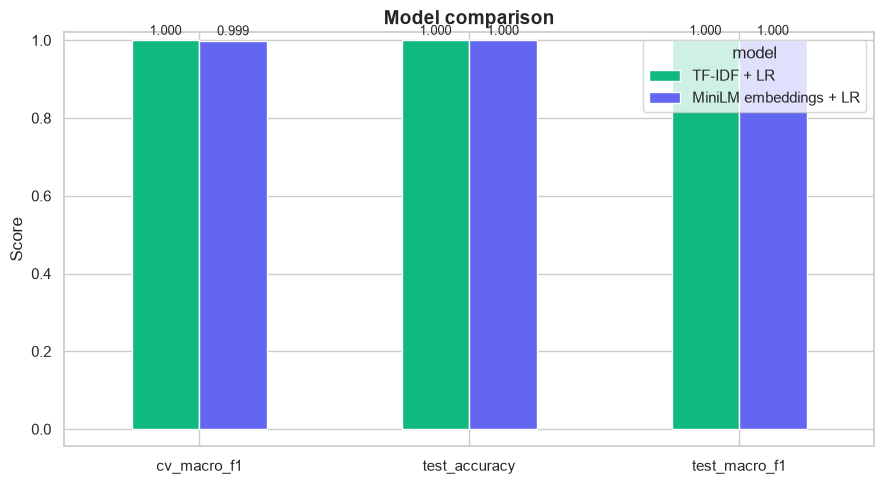

In [13]:
# ── Cell 13 : Side-by-side score table + chart ──────────────────────────────
results = pd.DataFrame([res_tfidf, res_emb]).set_index("model")
results = results[["cv_macro_f1", "cv_log_loss", "test_accuracy", "test_macro_f1", "test_log_loss"]].round(4)
display(results)   # log-loss columns: lower is better; the rest: higher is better

ax = results[["cv_macro_f1", "test_accuracy", "test_macro_f1"]].T.plot(
    kind="bar", figsize=(9, 5), color=["#10B981", "#6366F1"], rot=0
)
ax.set_ylim(min(0.5, results.values.min() - 0.05), 1.02)
ax.set_title("Model comparison", fontsize=14, fontweight="bold")
ax.set_ylabel("Score")
for c in ax.containers:
    ax.bar_label(c, fmt="%.3f", padding=2, fontsize=9)
plt.tight_layout()
plt.show()

In [14]:
# ── Cell 14 : Per-role F1 for each model ────────────────────────────────────
from sklearn.metrics import precision_recall_fscore_support

labels = sorted(y.unique())
def per_role_f1(y_true, y_pred):
    _, _, f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=labels, zero_division=0)
    return pd.Series(f1, index=labels)

per_role = pd.DataFrame({
    "TF-IDF + LR": per_role_f1(y_test, pred_tfidf),
    "MiniLM + LR": per_role_f1(y_test, pred_emb),
}).round(3)
per_role.sort_values("TF-IDF + LR")

,TF-IDF + LR,MiniLM + LR
Accountant,1.0,1.0
Business Analyst,1.0,1.0
Cyber Security,1.0,1.0
Data Analyst,1.0,1.0
Data Science,1.0,1.0
Database Administrator,1.0,1.0
Finance,1.0,1.0
Graphic Designer,1.0,1.0
HR,1.0,1.0
Machine Learning Engineer,1.0,1.0


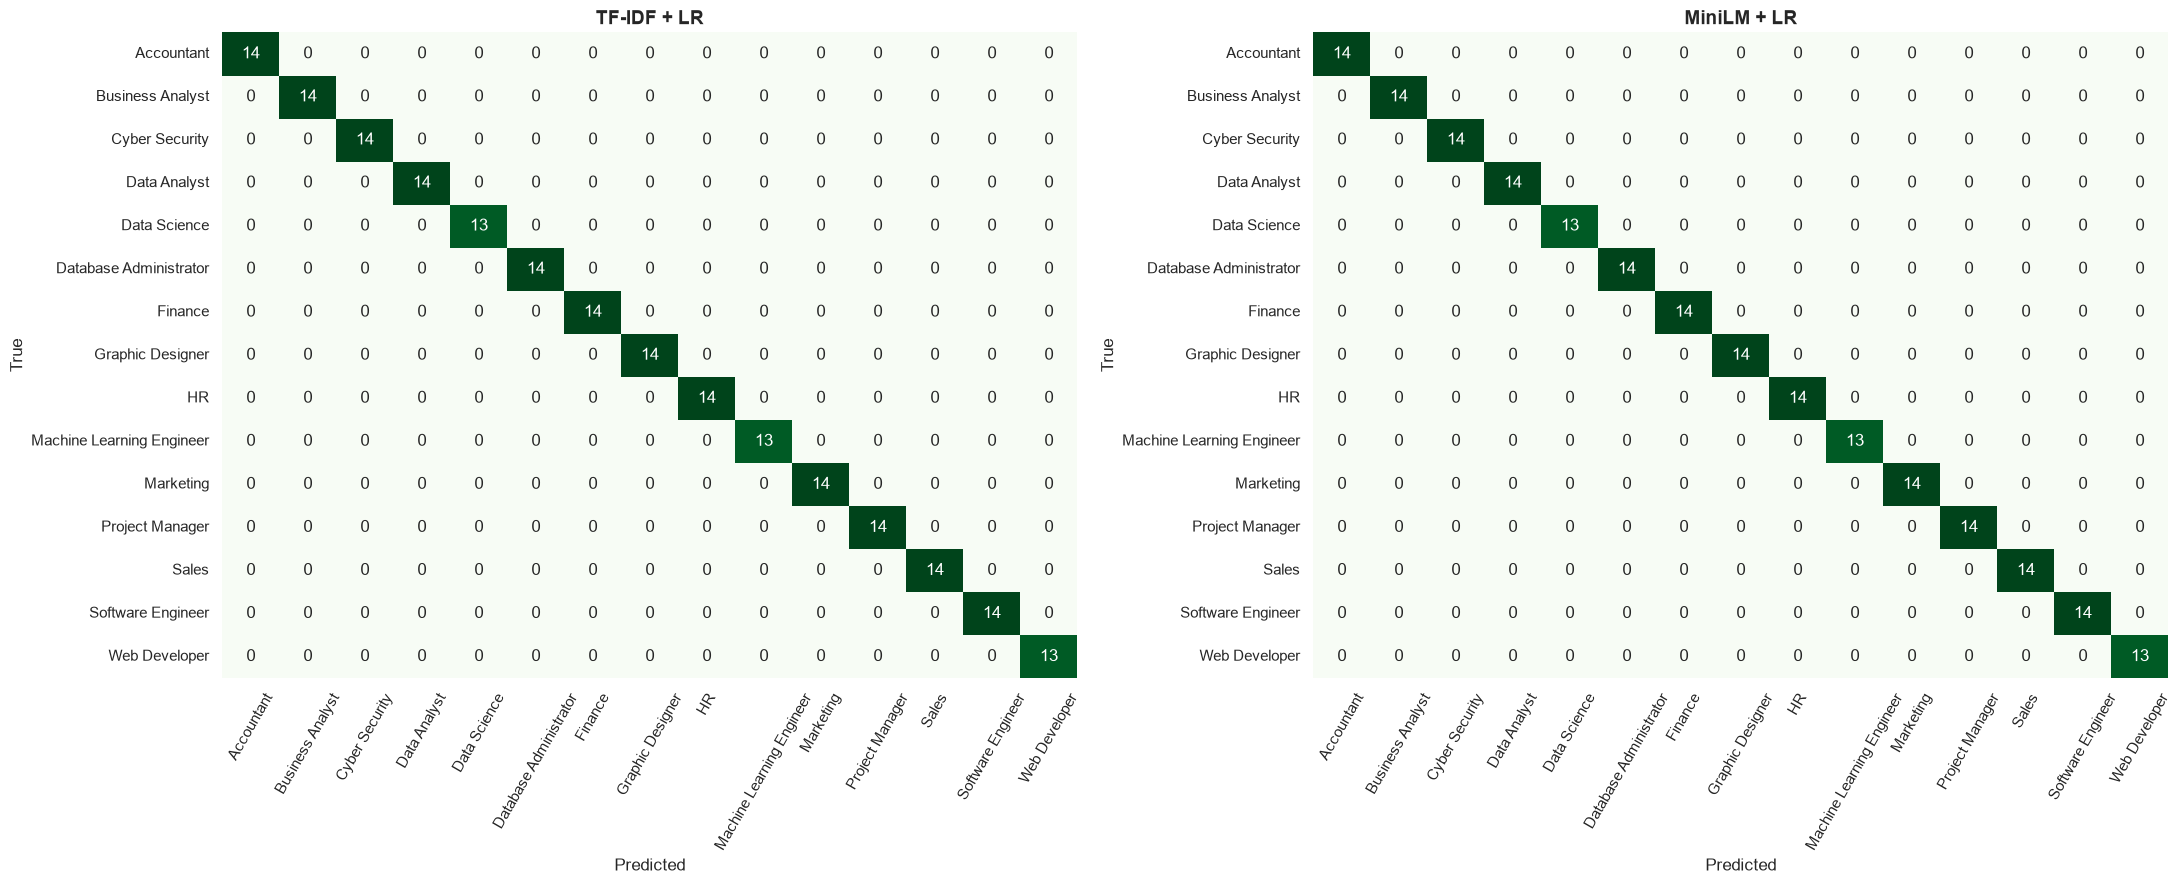


Most common mix-ups — TF-IDF + LR:
  (none: no mistakes on the test set)

Most common mix-ups — MiniLM + LR:
  (none: no mistakes on the test set)


In [15]:
# ── Cell 15 : Confusion matrices ────────────────────────────────────────────
# Rows = true role, columns = predicted role. Numbers off the diagonal are mistakes.
fig, axes = plt.subplots(1, 2, figsize=(22, 9))
for ax, (title, pred) in zip(axes, [("TF-IDF + LR", pred_tfidf), ("MiniLM + LR", pred_emb)]):
    cm = confusion_matrix(y_test, pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", cbar=False,
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.tick_params(axis="x", rotation=60)
plt.tight_layout()
plt.show()

# The same information as a plain list: the most common mix-ups.
def top_confusions(y_true, y_pred, n=5):
    cm = pd.DataFrame(confusion_matrix(y_true, y_pred, labels=labels), index=labels, columns=labels)
    pairs = [(t, p, cm.loc[t, p]) for t in labels for p in labels if t != p and cm.loc[t, p] > 0]
    return sorted(pairs, key=lambda r: -r[2])[:n]

for title, pred in [("TF-IDF + LR", pred_tfidf), ("MiniLM + LR", pred_emb)]:
    print(f"\nMost common mix-ups — {title}:")
    mix = top_confusions(y_test, pred)
    if not mix:
        print("  (none: no mistakes on the test set)")
    for t, p, c in mix:
        print(f"  true '{t}'  ->  predicted '{p}'   x{c}")

In [16]:
# ── Cell 16 : Full classification report for each model ─────────────────────
print("=== TF-IDF + LR ===")
print(classification_report(y_test, pred_tfidf, zero_division=0))
print("=== MiniLM embeddings + LR ===")
print(classification_report(y_test, pred_emb, zero_division=0))

=== TF-IDF + LR ===
                           precision    recall  f1-score   support

               Accountant       1.00      1.00      1.00        14
         Business Analyst       1.00      1.00      1.00        14
           Cyber Security       1.00      1.00      1.00        14
             Data Analyst       1.00      1.00      1.00        14
             Data Science       1.00      1.00      1.00        13
   Database Administrator       1.00      1.00      1.00        14
                  Finance       1.00      1.00      1.00        14
         Graphic Designer       1.00      1.00      1.00        14
                       HR       1.00      1.00      1.00        14
Machine Learning Engineer       1.00      1.00      1.00        13
                Marketing       1.00      1.00      1.00        14
          Project Manager       1.00      1.00      1.00        14
                    Sales       1.00      1.00      1.00        14
        Software Engineer       1.00     

### How to read the comparison
- **Accuracy** = share of test resumes given the correct role. **Macro-F1** = the average per-role score
  (it punishes a model that is great on most roles but poor on one).
- **CV macro-F1** was measured *only on training data*, so it is the fair number for **choosing** a model.
  The **test** numbers are the final, unbiased grade.
- In the confusion matrix, **a perfect model has numbers only on the diagonal**. Look at which roles overlap in the
  real world — for example *Data Science*, *Machine Learning Engineer* and *Data Analyst* share many skills
  (Python, SQL, statistics), so they are the most likely to be confused with each other.

> ⚠ **Read near-perfect scores with suspicion.** If both models score at or near 100%, the honest reading is
> usually *"this dataset is easy"*, not *"we built a perfect resume reader"*. The resumes look templated: each role has
> its own distinctive skill vocabulary, and job titles often appear in the text. When scores are this close, the
> A-vs-B comparison cannot really tell the models apart. The next cell stress-tests the model to see how fragile
> or robust that performance is.

### Stress test — is the model reading skills, or just spotting the job title?

Two quick experiments with the **TF-IDF model** (they need no extra downloads):

1. **Hide the role name.** Delete every word of the role's name (e.g. "Database", "Administrator") from *all* resumes,
   retrain, and test. If accuracy collapses, the model was just spotting the title.
2. **Shorten the resume.** Keep only a random 25-word snippet of each test resume. A model that has really learned
   what roles look like should still do reasonably well.

In [17]:
# ── Cell 16b : Stress tests ─────────────────────────────────────────────────
import re

# --- Experiment 1: remove the words that make up each resume's own role name
def hide_role_words(text, role):
    for word in re.findall(r"[A-Za-z]+", role):
        if word.lower() != "and":
            text = re.sub(rf"\b{word}\b", "", text, flags=re.IGNORECASE)
    return text

X_train_hide = pd.Series([hide_role_words(t, y_train[i]) for i, t in X_train.items()], index=X_train.index)
X_test_hide  = pd.Series([hide_role_words(t, y_test[i])  for i, t in X_test.items()],  index=X_test.index)

m1 = clone(grid_tfidf.best_estimator_).fit(X_train_hide, y_train)
print(f"1) Role-name words removed  -> test accuracy: {accuracy_score(y_test, m1.predict(X_test_hide)):.4f}")

# --- Experiment 2: test on short random snippets (the model is trained as usual)
rng = np.random.default_rng(0)
def random_window(text, n_words=25):
    words = text.split()
    start = rng.integers(0, max(1, len(words) - n_words))
    return " ".join(words[start:start + n_words])

snippets = X_test.map(random_window)
print(f"2) 25-word snippets only    -> test accuracy: {accuracy_score(y_test, grid_tfidf.predict(snippets)):.4f}")

1) Role-name words removed  -> test accuracy: 1.0000
2) 25-word snippets only    -> test accuracy: 0.9903


**How to read this:** if accuracy barely moves in experiment 1, the model is **not** just matching the job title; it is
using the skill and tool vocabulary. That is genuinely useful, but it also tells us the skill lists in this dataset are
very role-specific. Real resumes mix skills across roles more, so expect lower real-world accuracy.
If experiment 2 stays high, the signal is spread across the whole text rather than hidden in one phrase.

---
## Step 8 — Pick the best model and save it with `joblib`

**How we choose:** we pick the model with the higher **cross-validation macro-F1** (not the test score — choosing
on the test set would quietly leak the "exam" into our decision).

**A tie-breaker for simplicity:** the embedding model needs PyTorch and a ~90 MB model loaded in your API, whereas
the TF-IDF model is a tiny file with no extra dependencies. So the embedding model must beat TF-IDF by more than
`MARGIN` (0.5 points) to win. Set `MARGIN = 0` if you want a strict "highest score wins".

**Final refit:** once the winner and its best `C` are chosen, we re-train it on **all** resumes (train + test).
With only ~1,000 samples, the extra 20% of data helps. The honest scores above still describe how this kind of
model performs on unseen data.

**What gets saved:** one file, `app/models/job_classifier.joblib`, holding a small dictionary:
the model type, the trained model, the list of roles, the scores, and how many resumes it was trained on.
`app/recommender.py` reads it back.

In [18]:
# ── Cell 17 : Choose the winner ─────────────────────────────────────────────
MARGIN = 0.005   # embeddings must beat TF-IDF by this much (CV macro-F1) to be chosen

cv_tfidf, cv_emb = res_tfidf["cv_macro_f1"], res_emb["cv_macro_f1"]
use_embedding = cv_emb > cv_tfidf + MARGIN

best_name = "MiniLM embeddings + LR" if use_embedding else "TF-IDF + LR"
best_kind = "embedding" if use_embedding else "tfidf"
best_res  = res_emb if use_embedding else res_tfidf

print(f"CV macro-F1  TF-IDF: {cv_tfidf:.4f} | Embeddings: {cv_emb:.4f} | margin needed: {MARGIN}")
print(f"WINNER -> {best_name}  (kind='{best_kind}')")

CV macro-F1  TF-IDF: 1.0000 | Embeddings: 0.9988 | margin needed: 0.005
WINNER -> TF-IDF + LR  (kind='tfidf')


In [19]:
# ── Cell 18 : Refit on ALL data and save ────────────────────────────────────
MODEL_DIR.mkdir(parents=True, exist_ok=True)

if best_kind == "tfidf":
    final_estimator = clone(grid_tfidf.best_estimator_).fit(X, y)     # raw (cleaned) text in
else:
    X_all_emb = np.vstack([X_train_emb, X_test_emb])
    y_all = pd.concat([y_train, y_test])
    final_estimator = clone(grid_emb.best_estimator_).fit(X_all_emb, y_all)  # vectors in

bundle = {
    "kind": best_kind,                       # tells recommender.py how to feed the model
    "model_name": best_name,
    "estimator": final_estimator,
    "classes": [str(c) for c in final_estimator.classes_],
    "metrics": {
        "cv_macro_f1":   round(float(best_res["cv_macro_f1"]), 4),
        "test_accuracy": round(float(best_res["test_accuracy"]), 4),
        "test_macro_f1": round(float(best_res["test_macro_f1"]), 4),
    },
    "trained_on": int(len(df)),
    "sklearn_version": sklearn.__version__,
    "embedding_model": "all-MiniLM-L6-v2" if best_kind == "embedding" else None,
}
joblib.dump(bundle, MODEL_PATH, compress=3)

print("Saved ->", MODEL_PATH)
print(f"File size: {MODEL_PATH.stat().st_size / 1024:.0f} KB")
print("Roles   :", bundle["classes"])
print("Metrics :", bundle["metrics"])

Saved -> C:\Users\PMLS\resume-analyzer\app\models\job_classifier.joblib
File size: 1570 KB
Roles   : ['Accountant', 'Business Analyst', 'Cyber Security', 'Data Analyst', 'Data Science', 'Database Administrator', 'Finance', 'Graphic Designer', 'HR', 'Machine Learning Engineer', 'Marketing', 'Project Manager', 'Sales', 'Software Engineer', 'Web Developer']
Metrics : {'cv_macro_f1': 1.0, 'test_accuracy': 1.0, 'test_macro_f1': 1.0}


---
## Step 9 — Use it: `recommend_roles()`

Now the payoff. `recommend_roles(resume_text, top_k=4)` in `app/recommender.py`:

1. Cleans the text with `light_clean()` (same as training).
2. Loads the saved model (once, then cached).
3. Gets a probability for every role.
4. Returns the **top 4** roles with their probability in percent.

We try two **brand-new resumes written by hand** (neither is in the dataset, so the model has truly never seen them).
Note: the saved model was re-trained on *all* dataset resumes, so testing it on a dataset row would not be a fair
check, which is why we use fresh text here.

In [20]:
# ── Cell 19 : Try recommend_roles ───────────────────────────────────────────
import importlib
import app.recommender as recommender
recommender.load_model.cache_clear()          # make sure we read the file we just saved
importlib.reload(recommender)

my_resume = '''
Experienced analyst with 4 years turning raw data into dashboards and decisions.
Built Power BI and Tableau dashboards for sales and operations teams.
Wrote SQL queries to clean, join and aggregate large datasets, and automated weekly reports with Python and pandas.
Ran A/B tests and presented findings to stakeholders. Bachelor's degree in Statistics.
'''

print("Brand-new resume:")
for r in recommender.recommend_roles(my_resume, top_k=4):
    print(f"  {r['role']:<28} {r['probability_percent']:>6.2f}%")

my_resume_2 = '''
Creative professional with 3 years of experience planning social media campaigns and email newsletters.
Grew Instagram following by 80% through content strategy, SEO-optimised blog posts and paid ads.
Managed a monthly advertising budget, tracked campaign performance in Google Analytics and reported ROI to leadership.
'''

print("\nSecond brand-new resume:")
for r in recommender.recommend_roles(my_resume_2):
    print(f"  {r['role']:<28} {r['probability_percent']:>6.2f}%")

Brand-new resume:
  Data Analyst                  75.80%
  Data Science                   7.95%
  Finance                        2.01%
  Cyber Security                 1.51%

Second brand-new resume:
  Marketing                     94.04%
  Graphic Designer               0.75%
  Data Analyst                   0.61%
  Project Manager                0.57%


In [21]:
# ── Cell 20 : Sanity checks on the saved model ──────────────────────────────
# 1. Probabilities from a full prediction should add up to ~100%.
all_roles = recommender.recommend_roles(my_resume, top_k=100)   # capped at the number of roles
print("Roles returned:", len(all_roles), "| probabilities sum to:",
      round(sum(r["probability_percent"] for r in all_roles), 1), "%")

# 2. top_k is respected, and bad input is rejected with a clear error.
assert len(recommender.recommend_roles(my_resume, top_k=2)) == 2
for bad in ["", "   "]:
    try:
        recommender.recommend_roles(bad)
    except ValueError as e:
        print("Empty text rejected  ->", e)

Roles returned: 15 | probabilities sum to: 100.0 %
Empty text rejected  -> resume_text must not be empty.
Empty text rejected  -> resume_text must not be empty.


---
## Summary & what to remember

- We used the **real** `resume_dataset.csv` (1,034 resumes, 15 balanced roles) and cleaned it with your `light_clean()`.
- We trained **two** models on an identical stratified split and tuned both with 5-fold cross-validation:
  **TF-IDF + Logistic Regression** and **MiniLM embeddings + Logistic Regression**.
- We chose the winner on **cross-validation** (not the test set), with a small preference for the simpler model.
- The winner is saved at `app/models/job_classifier.joblib`, and `recommend_roles()` serves it.

**Limits to keep in mind**
- The model only knows these **15 roles**. A resume for a nurse will still get 4 "best guesses" from this list.
- Probabilities show *relative* fit among the 15 roles, not absolute quality. A low top score (e.g. 30%) means the
  resume sits between several roles.
- The saved file is tied to the scikit-learn version it was trained with (recorded in the bundle).
  If you upgrade scikit-learn, simply re-run this notebook.
- Scores on this templated dataset are likely higher than on messy real-world resumes.

**Ideas for later:** add a `/recommend-roles` endpoint in `main.py`, show the top-4 roles on the dashboard,
or try more varied real resumes to measure real-world accuracy.